# Logistic Regression | Regresión Logística

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.model_selection import train_test_split
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings

In [2]:
def warn(*args, **kwargs):
    pass


warnings.warn = warn

En **Machine Learning**, el algoritmo de **regresión logística** es un **algoritmo de clasificación**, **no** de regresión, a pesar de su nombre confuso.

### ¿Por qué se llama "regresión" si clasifica?

El nombre viene de sus orígenes en estadística, donde se utilizaba una transformación logística sobre una regresión lineal para modelar probabilidades. Sin embargo, su uso principal en ML es para:

* **Clasificación binaria**: por ejemplo, predecir si un email es *spam* o *no spam*.
* También se puede extender a **clasificación multiclase** mediante estrategias como **one-vs-rest**.

### ¿Cómo funciona?

* Modela la probabilidad de pertenencia a una clase.
* La salida es continua (una probabilidad entre 0 y 1), pero se **umbraliza** (por ejemplo, a 0.5) para decidir la clase.
* Utiliza la **función sigmoide** para convertir una combinación lineal de características en una probabilidad.

### En resumen:

| Aspecto           | Regresión Logística                |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Clasificación                      |
| Salida del modelo | Probabilidad entre 0 y 1           |
| Toma de decisión  | Por umbral (e.g. 0.5)              |
| Nombre confuso    | Proviene de la estadística clásica |


### 7.1. Función logarítmica <a name="funcion"></a>


Variable Dependiente: En la regresión logística, la variable dependiente
𝑦 representa una variable categórica binaria, típicamente codificada como 0 o 1.

Variables Independientes: Son variables predictoras 𝑋1,𝑋2,…,𝑋𝑝 que se utilizan para predecir la probabilidad de que 𝑦 sea 1.

Utiliza la función logística (también conocida como sigmoide) para modelar la relación entre las variables independientes y la probabilidad de que
𝑦 sea 1:

### 7.2. Umbral de decisión <a name="umbral"></a>

Dado que la regresión logística predice la probabilidad de que
𝑦 sea 1, es necesario definir un umbral (por ejemplo, 0.5) para convertir estas probabilidades en predicciones binarias (0 o 1).

Por defecto, `predict()` en scikit-learn utiliza un umbral de 0.5 para transformar las probabilidades pronosticadas en etiquetas binarias.

Puedes ajustar el umbral de decisión para convertir las probabilidades pronosticadas.

```py
# Suponiendo que 'model' es tu modelo de regresión logística ya entrenado
y_proba = model.predict_proba(X_test)

# Suponiendo que deseas ajustar el umbral a 0.3
threshold = 0.3
y_pred_threshold = np.where(y_proba[:, 1] > threshold, 1, 0)

# Evaluar el rendimiento con el nuevo umbral
accuracy_score(y_test, y_pred_threshold)
```

### 7.3. Hiperparámetros <a name="parametros"></a>

Podemos construir un modelo de regresión logística fácilmente en Python utilizando la librería `scikit-learn` y la función `LogisticRegression`.

Algunos de sus parámetros más importantes y los primeros en los que debemos centrarnos son:

- `penalty`: Este parámetro se usa para prevenir el sobreajuste (*overfitting*) del modelo. Este parámetro se puede configurar para que no exista penalización y para graduarla desde niveles muy leves hasta muy altos.

- `C`: Este parámetro determina la complejidad del modelo. Es el inverso del parámetro anterior. Es un número decimal que determina cómo de simple queremos que sea el modelo. Cuanto mayor sea el número, más complejo será el modelo y más se adaptará a la muestra de entrenamiento (aumentando la probabilidad del [sobreajuste](https://4geeks.com/es/lesson/basicos-de-machine-learning#Sobreajuste-de-modelos)).

- `solver`: Algoritmo de regresión que se utilizará para entrenar al modelo. Dependiendo del tamaño del conjunto de datos, de las clases a predecir, del nivel de sobreajuste que estemos dispuestos a asumir o del nivel de precisión, elegiremos una implementación u otra.

- `max_iter`: Número máximo de iteraciones.

Otro parámetro muy importante es el `random_state`, que controla la semilla de generación aleatoria que requieren algunos de los solvers del modelo. Este parámetro es crucial para asegurar la replicabilidad.

## Ejemplo Titanic

En el conjunto de datos del Titanic tenemos más de una característica, y con la regresión logística predecimos si sobrevivirán o no.

Si el valor que predice el modelo fuera 0.85, eso significaría que la persona tiene un 85% de probabilidades de sobrevivir y un 15% de no hacerlo.

Así, debemos establecer un límite (threshold) para poder realizar la clasificación (respondemos a la siguiente pregunta: ¿a partir de qué valor de probabilidad podemos asumir que la persona sobrevive o no?).

Supongamos que ese valor es el 50%, es decir, que cuando la probabilidad es mayor o igual a 0.5, el valor es 1 (sobrevive), y cuando la probabilidad es menor a 0.5, el valor es 0 (no sobrevive).

Además, tenemos que saber también que el proceso de entrenar y usar el modelo viene después del análisis exploratorio (EDA), así que necesitaremos partir de él.

In [3]:
train_data = pd.read_csv("../../data/clean-titanic-train.csv")
test_data = pd.read_csv("../../data/clean-titanic-test.csv")

train_data.head()

,Pclass,Fare,Sex_n,Embarked_n,FamMembers,Survived
0,2.0,10.500,1.0,0.0,0.0,0
1,2.0,26.000,0.0,0.0,1.0,1
2,3.0,7.750,1.0,2.0,0.0,1
3,3.0,16.700,1.0,0.0,2.0,1
4,3.0,34.375,1.0,0.0,4.0,0


El conjunto `train` lo utilizaremos para entrenar el modelo, mientras que con el `test` lo evaluaremos para medir su grado de efectividad. Dividiremos también las predictoras de las características.

In [4]:
X_train = train_data.drop(["Survived"], axis=1)
y_train = train_data["Survived"]

X_test = test_data.drop(["Survived"], axis=1)
y_test = test_data["Survived"]

##### Paso 2: Inicialización y entrenamiento del modelo

In [5]:
# Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)
model = LogisticRegression(random_state=18)

# Entrena
model.fit(X_train, y_train)

LogisticRegression(random_state=18)

##### Paso 3: Predicción del modelo

Una vez se ha entrenado el modelo, se puede utilizar para predecir con el conjunto de datos de prueba.

In [6]:
X_test.shape

(262, 5)

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1])

In [18]:
len(y_pred)

262

Existe una gran cantidad de métricas para medir la efectividad de un modelo a la hora de predecir, entre ellas la **precisión** (*accuracy*), que es la fracción de predicciones que el modelo realizó correctamente.

In [8]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.851145038167939

El modelo predice con un  85% de efectividad.

El valor anterior se interpretaría como que el modelo ha predicho, de 262 pasajeros, el resultado de supervivencia de 222 de ellos (si sobrevivían o no) correctamente.

Además de la puntuación (*score*) del modelo observada, es común que en los problemas de clasificación se construya una **matriz de confusión** (*confusion matrix*), que es una tabla que se organiza de tal manera que cada fila de la matriz representa las instancias de una clase predicha, mientras que cada columna representa las instancias de una clase real:

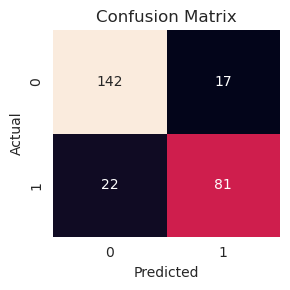

In [9]:
titanic_cm = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(titanic_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

La interpretación de una matriz de confusión es la siguiente:

- **Verdaderos positivos** (*TP, True positive*): Se corresponde con el número `142` y son los casos en los que el modelo predijo positivo (no supervivencia) y la clase real también es positiva.
- **Verdaderos negativos** (*TN, False negative*): Se corresponde con el número `81` y son los casos en los que el modelo predijo negativo (supervivencia) y la clase real también es negativa.
- **Falsos positivos** (*FP, False positive*): Se corresponde con el número `22` y son los casos en los que el modelo predijo positivo y la clase real es negativa.
- **Falsos negativos** (*FN, False negative*): Se corresponde con el número `17` y son los casos en los que el modelo predijo negativo y la clase real es positiva.

Estas cuatro medidas se utilizan a menudo para calcular métricas más complejas.

##### Paso 4: Optimización de resultados

Como hemos visto, el modelo base (con todos los parámetros predefinidos) de la regresión logística obtiene poco más de un 84% de precisión. Sin embargo, el hecho de modificar los parámetros del modelo podría suponer una mejora (o empeoramiento) significativos de los resultados. Existen varias estrategias como los modelos regularizados.

In [10]:
7 * 4 * 5

140

In [11]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la cuadrícula
grid = GridSearchCV(model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=18),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [12]:
grid.fit(X_train, y_train)

grid.best_params_

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Como vemos, los parámetros optimizados utilizando esta técnica son:

- `C`: 1
- `penalty`: l1
- `solver`: liblinear

Además, siempre debemos

In [13]:
grid.best_estimator_

LogisticRegression(C=1, penalty='l1', random_state=18, solver='liblinear')

s utilizar el conjunto de datos de entrenamiento para ajustarlo. Ahora solo tenemos que repetir el entrenamiento estableciendo estos parámetros en el modelo:

In [14]:
# best_model_grid = LogisticRegression(penalty='l1',
#                                      C=1,
#                                      solver='liblinear')
# best_model_grid.fit(X_train, y_train)
best_model_grid = grid.best_estimator_

y_pred_grid = best_model_grid.predict(X_train)

grid_accuracy = accuracy_score(y_train, y_pred_grid)

model_accuracy, grid_accuracy

(0.851145038167939, 0.8586437440305635)

In [20]:
grid_accuracy - model_accuracy

0.007498705862624577

Observamos que no hay una pequeña mejora.

In [15]:
# Definimos los parámetros que queremos ajustar
hyperparams = {'C': np.logspace(-4, 4, 20),
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model,
                                   hyperparams,
                                   n_iter=100,
                                   scoring="accuracy",
                                   cv=5,
                                   random_state=18)
random_search

RandomizedSearchCV(cv=5, estimator=LogisticRegression(random_state=18),
                   n_iter=100,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    None],
                                        'solver': ['newton-cg', 'lbfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   random_state=18, scoring='accuracy')

In [21]:
random_search.fit(X_train, y_train)

random_search.best_params_

{'solver': 'lbfgs', 'penalty': None, 'C': 0.615848211066026}

Como vemos, los parámetros optimizados utilizando esta técnica son:

- `C`: 29.7635
- `penalty`: l2
- `solver`: lbfgs

Con esta nueva hiperparametrización, reentrenamos el modelo:

In [17]:
model_random_search = LogisticRegression(penalty="l2",
                                         C=29.7635,
                                         solver="lbfgs")

model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.851145038167939

Como vemos, arroja el mismo nivel de precisión que la estrategia anterior. Esto quiere decir que con los medios e hiperparámetros que hemos intentado optimizar nos encontramos en un **máximo local**, esto es, que tendríamos que repetir la estrategia de optimización incluyendo otros hiperparámetros para mejorar los resultados del modelo, ya que solo jugando con el `penalty`, `C` y `solver` no vamos a mejorar el modelo más de lo que ya está.